In [1]:
import sys, pathlib
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "src" / "ml_textbook").exists():
        sys.path.insert(0, str(_p / "src"))
        break

# 07. 教師なし学習 — クラスタリング・次元削減・異常検知

> 各章は **直感 → 最小限の数式 → scikit-learn 実装 → 可視化 → 実験 → 演習** の順。本文は日本語、コードは英語、数式に日本語を入れない。

## この章で分かること

- **k-means** の仕組み(割り当て→更新)と $k$ の選び方(エルボー・シルエット)
- **GMM** の柔らかい割り当て、k-means との違い
- **階層的クラスタリング** とデンドログラム
- **PCA**(分散最大化)と **t-SNE / UMAP**(非線形な可視化)
- **異常検知**(Isolation Forest, LOF)
- 教師なしの結果は **解釈が要る** — 正解ラベルが無いので評価が難しい

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import plotly.io as pio
import plotly.graph_objects as go
pio.renderers.default = "plotly_mimetype+notebook_connected"

from ml_textbook import datasets, plotting, widgets

RANDOM_SEED = 0
np.random.seed(RANDOM_SEED)
print("setup ok")

setup ok


## 1. k-means — 重心への割り当てと更新

k-means は次を交互に繰り返し、**クラスタ内二乗和(inertia)** を最小化します:

1. **割り当て**: 各点を最も近い重心に割り当てる
2. **更新**: 各クラスタの重心をその点群の平均に移す

$$
\min_{C}\ \sum_{j=1}^{k}\sum_{x\in C_j}\lVert x - \mu_j\rVert^2
$$

下のスライダー(静的 HTML 可)で、反復ごとに重心が移動し収束する様子を見ます。

In [3]:
X, _ = datasets.make_blobs_dataset(n=400, centers=4, cluster_std=1.1, seed=0)
rng = np.random.default_rng(7)
k = 4
centroids = X[rng.choice(len(X), k, replace=False)].copy()

cent_hist, label_hist = [centroids.copy()], []
for _ in range(8):
    d = ((X[:, None, :] - centroids[None, :, :]) ** 2).sum(-1)
    labels = d.argmin(1)
    label_hist.append(labels.copy())
    centroids = np.array([X[labels == j].mean(0) if (labels == j).any() else centroids[j] for j in range(k)])
    cent_hist.append(centroids.copy())

def traces(i):
    labels = label_hist[i]
    c = cent_hist[i]
    return [
        go.Scatter(x=list(X[:, 0]), y=list(X[:, 1]), mode="markers",
                   marker={"color": list(map(int, labels)), "colorscale": "Viridis", "size": 6, "opacity": 0.7},
                   showlegend=False),
        go.Scatter(x=list(c[:, 0]), y=list(c[:, 1]), mode="markers",
                   marker={"color": "red", "symbol": "x", "size": 16, "line": {"width": 3}}, showlegend=False),
    ]

frames = [go.Frame(name=str(i + 1), data=traces(i), layout={"title": f"iteration {i + 1}"})
          for i in range(len(label_hist))]
fig = go.Figure(data=traces(0), frames=frames)
steps = [{"args": [[f.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
          "label": f.name, "method": "animate"} for f in frames]
fig.update_layout(sliders=[{"steps": steps, "currentvalue": {"prefix": "iteration = "}}],
                  title="k-means: assign then move centroids", width=620, height=560,
                  xaxis={"title": "x1"}, yaxis={"title": "x2", "scaleanchor": "x"},
                  margin={"l": 50, "r": 20, "t": 60, "b": 40})
fig.show()

## 2. $k$ をいくつにするか — エルボーとシルエット

正解クラスタ数は普通わかりません。二つの目安:

- **エルボー法**: inertia は $k$ を増やすと必ず下がる。下がり方が緩む「肘」を選ぶ。
- **シルエット係数**: 各点が「自分のクラスタにどれだけ馴染み、隣のクラスタからどれだけ離れているか」。
  $[-1, 1]$ で大きいほど良い。

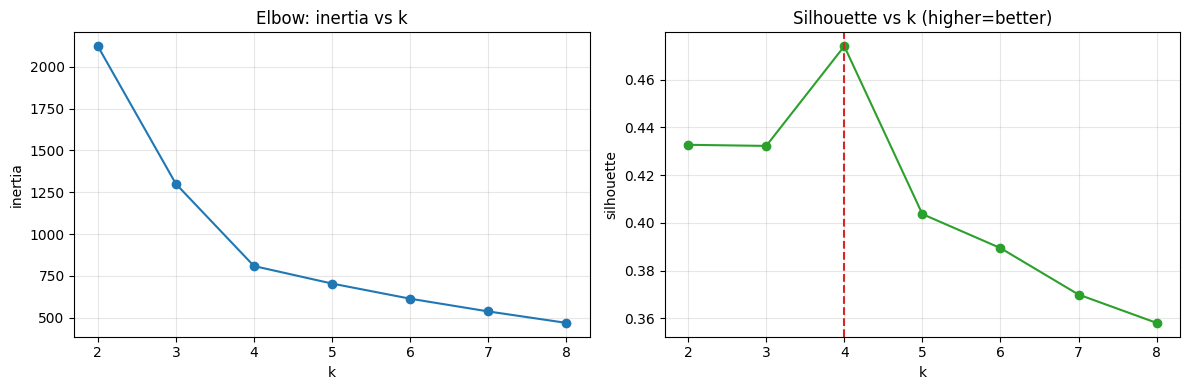

best k by silhouette: 4


In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 9)
inertia, sil = [], []
for kk in ks:
    km = KMeans(n_clusters=kk, n_init=10, random_state=0).fit(X)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(list(ks), inertia, "o-", color="#1f77b4"); axes[0].set_title("Elbow: inertia vs k")
axes[0].set_xlabel("k"); axes[0].set_ylabel("inertia"); axes[0].grid(alpha=0.3)
axes[1].plot(list(ks), sil, "o-", color="#2ca02c"); axes[1].set_title("Silhouette vs k (higher=better)")
axes[1].set_xlabel("k"); axes[1].set_ylabel("silhouette"); axes[1].grid(alpha=0.3)
axes[1].axvline(list(ks)[int(np.argmax(sil))], color="#d62728", ls="--")
plt.tight_layout(); plt.show()
print("best k by silhouette:", list(ks)[int(np.argmax(sil))])

## 3. GMM — 柔らかい(確率的)クラスタリング

k-means は各点を 1 クラスタに **きっぱり** 割り当てます。**ガウス混合モデル (GMM)** は
各点に「各クラスタに属する確率」を与え、楕円形のクラスタも表せます。

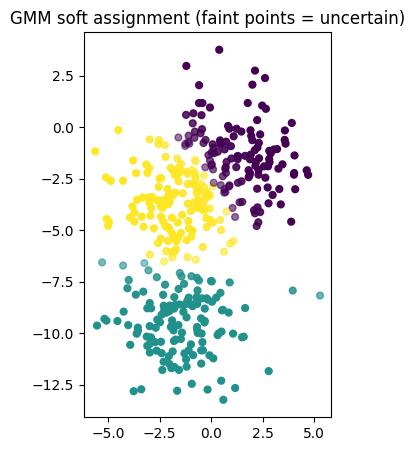

example soft memberships (first 3 points):
 [[0.95 0.   0.05]
 [0.01 0.   0.99]
 [0.   0.99 0.01]]


In [5]:
from sklearn.mixture import GaussianMixture

Xg, _ = datasets.make_blobs_dataset(n=400, centers=3, cluster_std=1.6, seed=2)
gmm = GaussianMixture(n_components=3, random_state=0).fit(Xg)
proba = gmm.predict_proba(Xg)
# Colour = most likely component; opacity = confidence (max probability).
conf = proba.max(1)
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(Xg[:, 0], Xg[:, 1], c=proba.argmax(1), cmap="viridis", s=24, alpha=np.clip(conf, 0.2, 1.0))
ax.set_title("GMM soft assignment (faint points = uncertain)"); ax.set_aspect("equal"); plt.show()
print("example soft memberships (first 3 points):\n", proba[:3].round(2))

### GMM の共分散を楕円で見る

各成分が学習した平均と **共分散** を 1σ / 2σ の楕円で重ねます。k-means の等方的な円と違い、
GMM は **傾いた楕円** でクラスタの形に追従できます。

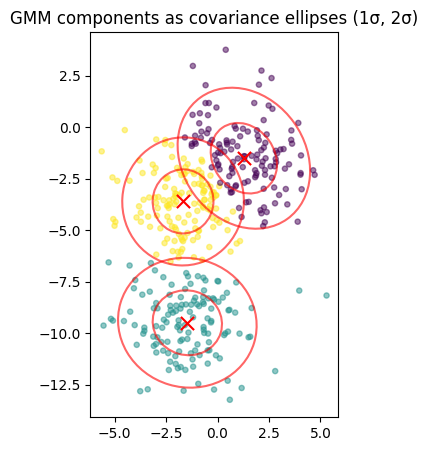

In [6]:
from matplotlib.patches import Ellipse

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(Xg[:, 0], Xg[:, 1], c=gmm.predict(Xg), cmap="viridis", s=14, alpha=0.5)
for mean, cov in zip(gmm.means_, gmm.covariances_):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = float(np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0])))
    for nsd in (1, 2):
        width, height = 2 * nsd * np.sqrt(vals)
        ax.add_patch(Ellipse(mean, width, height, angle=angle, fill=False, edgecolor="red", lw=1.5, alpha=0.6))
    ax.scatter(*mean, c="red", marker="x", s=90)
ax.set_title("GMM components as covariance ellipses (1σ, 2σ)"); ax.set_aspect("equal"); plt.show()

## 4. 階層的クラスタリング

距離の近いものから順にまとめていき、**デンドログラム**(樹形図)で構造を可視化します。
どの高さで切るかでクラスタ数が決まります。

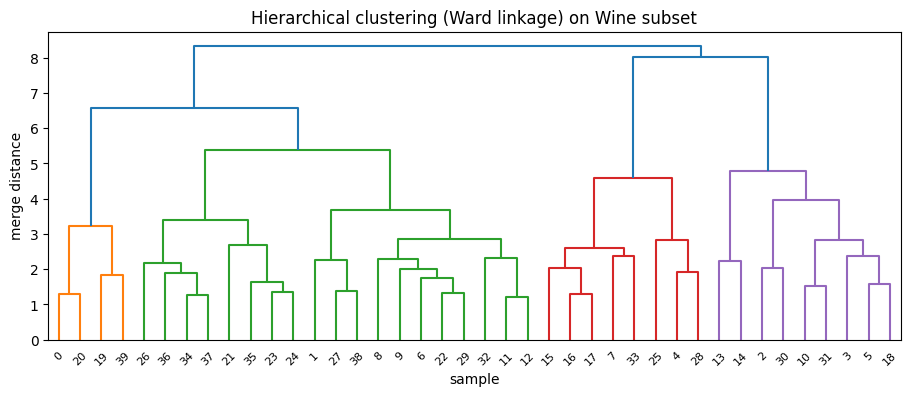

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage

wine = datasets.load_wine_dataset()
from sklearn.preprocessing import StandardScaler
Xw = StandardScaler().fit_transform(wine.data)[:40]   # small subset so the tree is readable
Z = linkage(Xw, method="ward")
fig, ax = plt.subplots(figsize=(11, 4))
dendrogram(Z, ax=ax, color_threshold=0.7 * Z[:, 2].max())
ax.set_title("Hierarchical clustering (Ward linkage) on Wine subset")
ax.set_xlabel("sample"); ax.set_ylabel("merge distance"); plt.show()

## 5. PCA — 分散を最大化する方向へ射影

PCA は、データの **分散が最大** になる直交方向(主成分)を見つけ、そこへ射影して次元を落とします。
情報(分散)をできるだけ保ったまま 2 次元へ潰せるので、可視化と前処理の定番です。

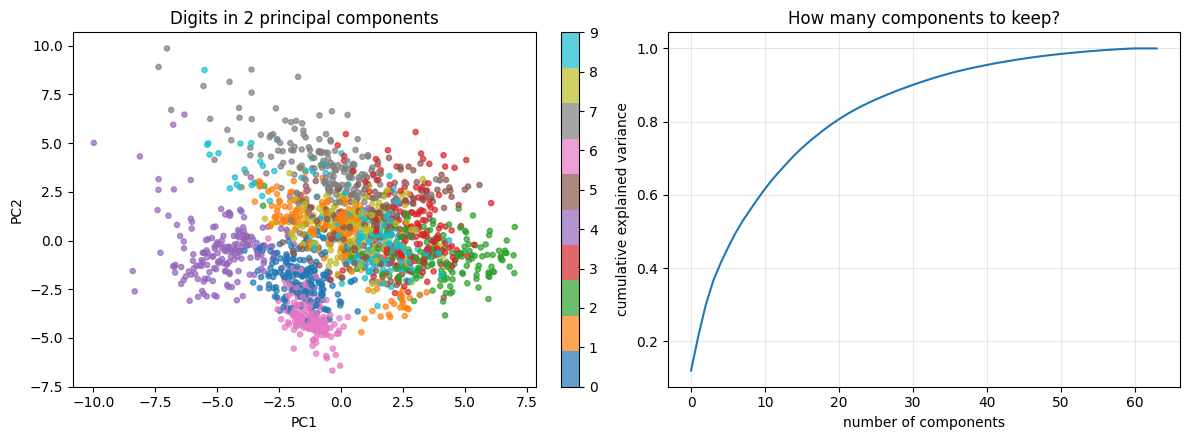

variance explained by first 2 PCs: 0.216


In [8]:
from sklearn.decomposition import PCA

digits = datasets.load_digits_dataset()
Xd = StandardScaler().fit_transform(digits.data)
pca = PCA(n_components=2, random_state=0).fit(Xd)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
plotting.plot_pca_projection(Xd, digits.target, ax=axes[0], title="Digits in 2 principal components")
full = PCA().fit(Xd)
axes[1].plot(np.cumsum(full.explained_variance_ratio_), color="#1f77b4")
axes[1].set_xlabel("number of components"); axes[1].set_ylabel("cumulative explained variance")
axes[1].set_title("How many components to keep?"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("variance explained by first 2 PCs:", float(pca.explained_variance_ratio_.sum()).__round__(3))

## 6. t-SNE / UMAP — 非線形な可視化

PCA は線形なので、曲がった構造は潰れがちです。**t-SNE**(と UMAP)は近傍関係を保つ非線形埋め込みで、
クラスタを見やすく分離します。ただし **距離やクラスタの大きさは信用しない**(可視化専用)。
UMAP は任意依存なので、入っていれば使い、無ければスキップします。

UMAP not installed — skipping (pip install umap-learn to enable).  ModuleNotFoundError


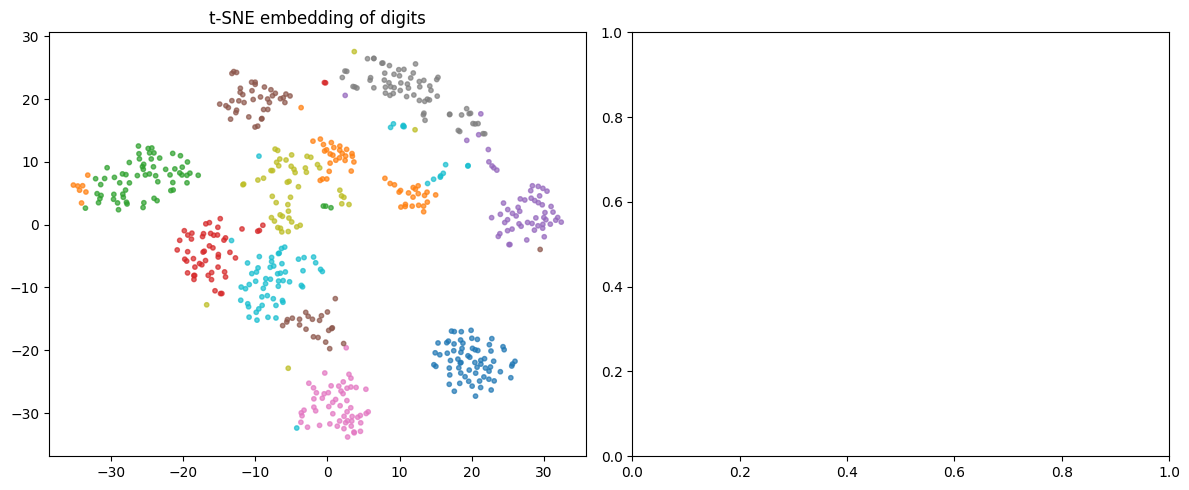

In [9]:
from sklearn.manifold import TSNE

sub = np.random.default_rng(0).choice(len(Xd), 600, replace=False)
ts = TSNE(n_components=2, perplexity=30, init="pca", random_state=0).fit_transform(Xd[sub])

ncols = 2
extra = []
try:
    import umap  # optional dependency
    um = umap.UMAP(n_components=2, random_state=0).fit_transform(Xd[sub])
    extra = [("UMAP", um)]
    ncols = 3
except Exception as e:
    print("UMAP not installed — skipping (pip install umap-learn to enable). ", type(e).__name__)

panels = [("t-SNE", ts)] + extra
fig, axes = plt.subplots(1, ncols, figsize=(6 * ncols, 5))
axes = np.atleast_1d(axes)
for ax, (name, emb) in zip(axes, panels):
    sc = ax.scatter(emb[:, 0], emb[:, 1], c=digits.target[sub], cmap="tab10", s=10, alpha=0.7)
    ax.set_title(f"{name} embedding of digits")
plt.tight_layout(); plt.show()

### インタラクティブ(JupyterLab のみ): k と PCA 成分数

k-means の k と、PCA の累積寄与率をスライダーで確認します。

In [10]:
widgets.kmeans_explorer(X)

interactive(children=(IntSlider(value=3, description='k', max=10, min=2), Output()), _dom_classes=('widget-int…

<function ml_textbook.widgets.kmeans_explorer.<locals>.draw(k)>

In [11]:
widgets.pca_components_explorer(Xd)

interactive(children=(IntSlider(value=2, description='comps', max=64, min=1), Output()), _dom_classes=('widget…

<function ml_textbook.widgets.pca_components_explorer.<locals>.draw(n_components)>

## 7. 異常検知 — 多数派から外れた点を見つける

正常データの構造を学び、そこから外れる点を **異常** とします。

- **Isolation Forest**: ランダムな分割で「すぐ孤立する」点を異常とみなす。
- **Local Outlier Factor (LOF)**: 周囲より密度が低い点を異常とみなす。

ラベル(正常/異常)があるので、ここでは ROC-AUC で答え合わせします(実務ではラベルが無いことが多い)。

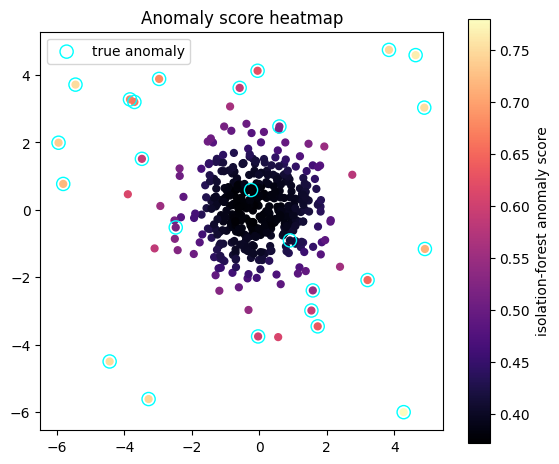

ROC-AUC  IsolationForest = 0.944
ROC-AUC  LOF             = 0.947


In [12]:
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import roc_auc_score

Xa, ya = datasets.make_anomaly_dataset(n_normal=400, n_anomalies=25, seed=0)
iso = IsolationForest(contamination=0.06, random_state=0).fit(Xa)
iso_score = -iso.score_samples(Xa)                       # higher = more anomalous
lof = LocalOutlierFactor(n_neighbors=20)
lof.fit_predict(Xa)
lof_score = -lof.negative_outlier_factor_

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(Xa[:, 0], Xa[:, 1], c=iso_score, cmap="magma", s=24)
ax.scatter(Xa[ya == 1, 0], Xa[ya == 1, 1], facecolors="none", edgecolors="cyan", s=90, label="true anomaly")
plt.colorbar(sc, ax=ax, label="isolation-forest anomaly score"); ax.legend()
ax.set_title("Anomaly score heatmap"); ax.set_aspect("equal"); plt.show()
print(f"ROC-AUC  IsolationForest = {roc_auc_score(ya, iso_score):.3f}")
print(f"ROC-AUC  LOF             = {roc_auc_score(ya, lof_score):.3f}")

## 8. まとめ

- **k-means** は割り当て↔更新で inertia を最小化。$k$ はエルボー/シルエットで選ぶ。スケーリング必須・球形前提。
- **GMM** は確率的(柔らかい)割り当てで楕円クラスタも表せる。
- **階層的クラスタリング** はデンドログラムで構造を見せ、切る高さで $k$ が決まる。
- **PCA** は分散最大の線形射影、**t-SNE/UMAP** は非線形可視化(距離は信用しない)。
- **異常検知** は正常構造からの逸脱を測る。ラベルが無いことが多く、評価と閾値設定が難所。
- 教師なしは正解が無い分、**結果の解釈と妥当性確認** が本質。

## 9. Exercises

1. k-means アニメで初期重心(`rng` の seed)を変え、収束先が変わる(局所解)ことを確認せよ。
2. エルボーとシルエットが異なる $k$ を示すデータを作り、どちらを信じるか考えよ。
3. GMM の `covariance_type` を "spherical"/"full" で変え、楕円クラスタの当てはまりを比べよ。
4. PCA を 10 成分にして digits をロジスティック回帰で分類し、64 次元のままと精度を比べよ。
5. (発展)Isolation Forest の `contamination` を変えて、検出される異常数と ROC-AUC の関係を調べよ。

## 10. Common Mistakes

- **k-means をスケーリングせず使う。** 大スケール特徴に支配される。
- **t-SNE のクラスタ間距離を解釈する。** t-SNE は局所構造専用。距離・サイズは無意味。
- **正解ラベルでクラスタ数を“こっそり”選ぶ。** 教師なしの建前が崩れる。
- **異常検知の `contamination` を当てずっぽうで決める。** ドメイン知識で見積もる。

## 11. Advanced Notes

**PCA と SVD。** 主成分は中心化データ $X$ の共分散行列の固有ベクトル、すなわち $X$ の特異値分解 (SVD) の
右特異ベクトル。寄与率は特異値の二乗に比例する。線形代数の姉妹本「行列分解・SVD・PCA」と地続き。